# 스프린트 미션 4: Python EDA 실습

### 1\. 데이터 불러오기

제공된 '건강검진정보_2024.csv' 파일을 Pandas DataFrame으로 불러온 후, 상위 5개 로우를 출력하세요.  

---
*한글 파일이기 때문에 `encoding='cp949'`이라고 타입을 지정해 불러와야 합니다.

In [2]:
# 필요한 라이브러리를 import한 후 데이터를 불러오는 코드를 입력하세요
import platform
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# OS에 따른 폰트 설정
os_name = platform.system()

if os_name == 'Windows': # 윈도우
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif os_name == 'Darwin': # 맥, macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux (Colab 등)
    # Colab 환경에서만 apt-get이 작동하므로 예외 처리
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'], rc={"axes.unicode_minus": False})

In [3]:
health_df = pd.read_csv('../data/건강검진정보_2024_20260325.csv', encoding='cp949')
health_df.head(3)


,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,1.0,1.0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,1.0,1.0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,1.0,1.0


미션 안내 문서에 정리되어 있는 데이터 설명을 참고해서 각 컬럼의 의미를 충분히 숙지한 후 다음 단계로 넘어가세요.  
필요하다면 상위 5개 외에 다른 로우들도 자유롭게 살펴보면서 데이터의 의미를 이해하는 시간을 가져보세요.

### 2\. Data Shape 확인

데이터가 몇 개의 컬럼과 로우로 이루어져있는지 확인합니다.

In [4]:
# Data Shape을 확인하는 코드를 입력하세요
health_df.shape

(1000000, 17)

### 3\. Data Type 확인
컬럼별 정보와 데이터 타입을 확인합니다.

In [5]:
# 컬럼별 정보와 데이터 타입을 확인하는 코드를 입력하세요
health_df.dtypes

기준년도         int64
가입자일련번호      int64
시도코드         int64
성별코드         int64
연령대코드        int64
신장           int64
체중           int64
허리둘레       float64
시력_좌       float64
시력_우       float64
청력_좌       float64
청력_우       float64
수축기혈압      float64
이완기혈압      float64
식전혈당       float64
흡연상태       float64
음주여부       float64
dtype: object

### 4\. 결측값 확인 및 처리
컬럼별 결측값(Null값)의 수를 확인하고, 해당 컬럼의 전체 데이터 중 결측값의 비중이 어느 정도인지도 계산해 보세요.   
이후 각 컬럼의 결측값을 어떻게 처리하면 좋을지 고민해서 적절히 처리해 보세요.

In [6]:
# 컬럼별 결측값 수를 확인하는 코드를 입력하세요
health_df.isna().sum()

기준년도          0
가입자일련번호       0
시도코드          0
성별코드          0
연령대코드         0
신장            0
체중            0
허리둘레        495
시력_좌        193
시력_우        192
청력_좌        148
청력_우        148
수축기혈압      5790
이완기혈압      5789
식전혈당       5847
흡연상태        118
음주여부         45
dtype: int64

In [7]:
# 컬럼별 결측값 비중을 확인하는 코드를 입력하세요
health_df.isna().mean()*100


기준년도       0.0000
가입자일련번호    0.0000
시도코드       0.0000
성별코드       0.0000
연령대코드      0.0000
신장         0.0000
체중         0.0000
허리둘레       0.0495
시력_좌       0.0193
시력_우       0.0192
청력_좌       0.0148
청력_우       0.0148
수축기혈압      0.5790
이완기혈압      0.5789
식전혈당       0.5847
흡연상태       0.0118
음주여부       0.0045
dtype: float64

In [8]:
# 컬럼별 결측값을 적절하게 처리하는 코드를 입력하세요
health_df = health_df.dropna()
health_df.isna().sum()

기준년도       0
가입자일련번호    0
시도코드       0
성별코드       0
연령대코드      0
신장         0
체중         0
허리둘레       0
시력_좌       0
시력_우       0
청력_좌       0
청력_우       0
수축기혈압      0
이완기혈압      0
식전혈당       0
흡연상태       0
음주여부       0
dtype: int64

### 5\. 중복값 확인 및 처리
중복된 데이터가 있는지도 확인하고 적절히 처리해 보세요.

In [9]:
# 중복값을 점검하고 처리하는 코드를 입력하세요
health_df.duplicated().sum()

np.int64(0)

### 6\. 이상치 확인 및 처리
컬럼별 데이터의 분포를 확인한 후 이상치로 의심되는 값이 있는지 점검합니다. 이상치로 판단되는 수치가 있다면 적절히 처리해 보세요.

In [10]:
# 데이터의 분포를 확인하는 코드를 입력하세요
health_df.describe()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
count,993215.0,9.932150e+05,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000
mean,2024.0,2.499613e+06,33.928804,1.481058,10.644872,162.784201,64.608030,81.549447,0.953954,0.951690,1.036181,1.034887,122.701553,75.230067,100.984602,1.537394,0.659607
std,0.0,1.443845e+06,12.509420,0.499641,3.052112,9.336620,14.026089,10.944535,0.569034,0.563613,0.198467,0.195078,14.593113,10.360325,22.996683,0.781136,0.473841
min,2024.0,9.000000e+00,11.000000,1.000000,5.000000,130.000000,30.000000,6.800000,0.100000,0.100000,1.000000,1.000000,60.000000,11.000000,17.000000,1.000000,0.000000
25%,2024.0,1.247471e+06,27.000000,1.000000,8.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,1.000000,0.000000
50%,2024.0,2.499667e+06,41.000000,1.000000,11.000000,165.000000,65.000000,81.100000,0.900000,0.900000,1.000000,1.000000,121.000000,75.000000,96.000000,1.000000,1.000000
75%,2024.0,3.749694e+06,43.000000,2.000000,13.000000,170.000000,75.000000,88.500000,1.200000,1.200000,1.000000,1.000000,132.000000,81.000000,106.000000,2.000000,1.000000
max,2024.0,5.000000e+06,49.000000,2.000000,18.000000,195.000000,135.000000,999.000000,9.900000,9.900000,3.000000,3.000000,271.000000,182.000000,991.000000,3.000000,1.000000


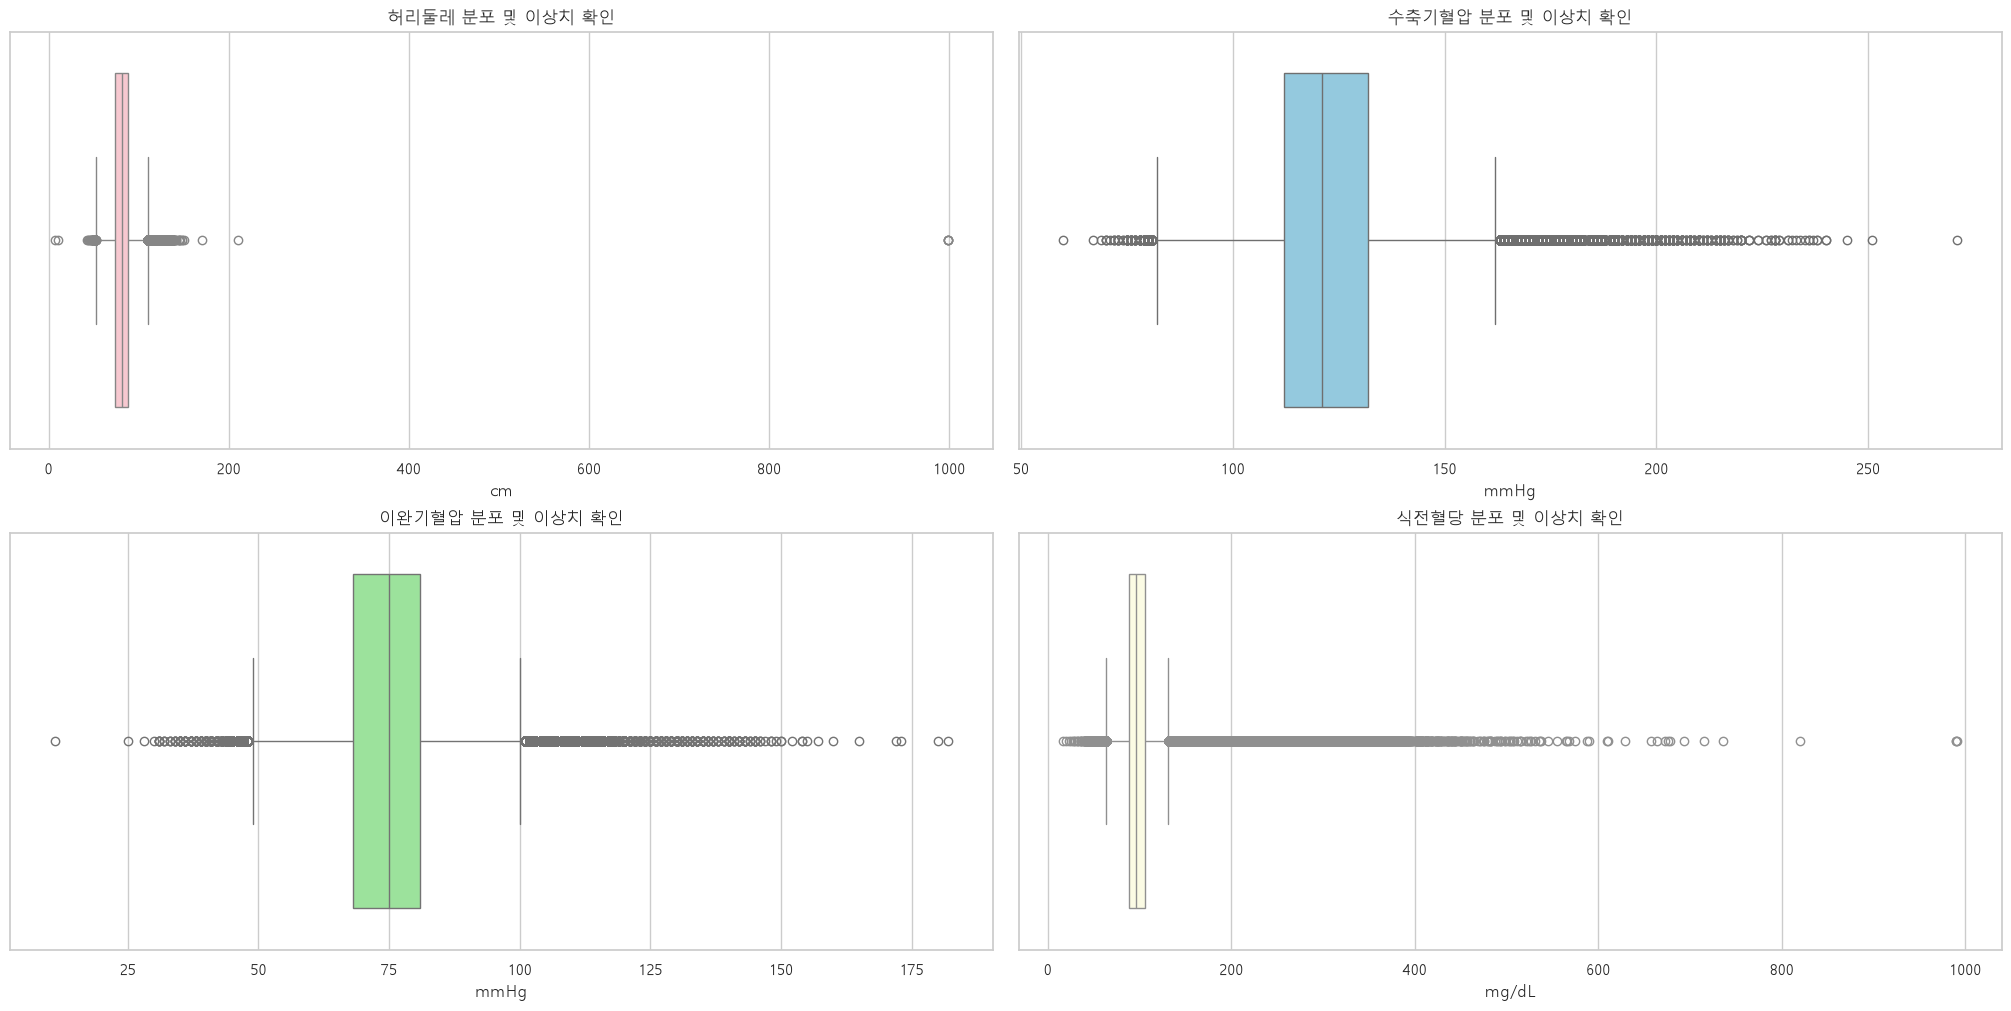

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10), constrained_layout=True)

sns.boxplot(data=health_df, x='허리둘레', color='pink', ax=axes[0, 0])
axes[0, 0].set_title('허리둘레 분포 및 이상치 확인')
axes[0, 0].set_xlabel('cm')

sns.boxplot(data=health_df, x='수축기혈압', color='skyblue', ax=axes[0, 1])
axes[0, 1].set_title('수축기혈압 분포 및 이상치 확인')
axes[0, 1].set_xlabel('mmHg')


sns.boxplot(data=health_df, x='이완기혈압', color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('이완기혈압 분포 및 이상치 확인')
axes[1, 0].set_xlabel('mmHg')

sns.boxplot(data=health_df, x='식전혈당', color='lightyellow', ax=axes[1, 1])
axes[1, 1].set_title('식전혈당 분포 및 이상치 확인')
axes[1, 1].set_xlabel('mg/dL')

plt.show()

In [12]:
health_df.sort_values(by ='허리둘레', ascending= True)['허리둘레'].head(10)

697568     6.8
480741    10.0
671704    43.0
599772    44.0
144278    45.3
145539    46.0
612724    47.0
615117    47.0
419188    48.0
435233    48.0
Name: 허리둘레, dtype: float64

In [13]:
health_df.sort_values(by ='허리둘레', ascending= False)['허리둘레'].head(20)

483743    999.0
362667    999.0
329570    999.0
257922    999.0
388284    210.0
636936    170.0
539226    150.0
643774    148.3
410219    148.0
486931    145.7
482523    145.0
859472    145.0
260500    145.0
929588    141.5
412884    141.0
623838    140.8
655472    139.1
502260    139.0
287327    139.0
480693    138.4
Name: 허리둘레, dtype: float64

In [14]:
q1 = health_df['수축기혈압'].quantile(0.25)
q3 = health_df['수축기혈압'].quantile(0.75)

iqr = q3-q1

수축기혈압q1 = q1-1.5*iqr
수축기혈압q1

np.float64(82.0)

In [15]:
q1 = health_df['이완기혈압'].quantile(0.25)
q3 = health_df['이완기혈압'].quantile(0.75)

iqr = q3-q1

이완기혈압q1 = q1-1.5*iqr
이완기혈압q1

np.float64(48.5)

In [16]:
q1 = health_df['식전혈당'].quantile(0.25)
q3 = health_df['식전혈당'].quantile(0.75)

iqr = q3-q1

식전혈당q1 = q1-1.5*iqr
식전혈당q1

np.float64(63.5)

In [17]:
health_df = health_df[(health_df['허리둘레'] > 10) & (health_df['허리둘레'] < 200)&
(health_df['청력_좌'] != 3) & (health_df['청력_우'] != 3)&
(health_df['수축기혈압'] >= 82)&
(health_df['이완기혈압'] >= 48.5)&
(health_df['식전혈당'] >= 63.5) & (health_df['식전혈당'] < 800)]


### 7\. 시도코드 & 연령대코드 정리
현재 이 데이터에는 `시도코드`와 `연령대코드` 컬럼이 숫자로 된 코드로 적혀 있어 알아보기가 어렵습니다.   
보다 직관적으로 분석할 수 있도록 두 컬럼의 코드를 실제 의미를 담은 문자열로 변경해 보세요.
- `시도코드`: 11 → "서울특별시", 26 → "부산광역시", ... 이런 식으로 치환
- `연령대코드`: 1 → "0-4", 2 → "5-9", ... 이런 식으로 치환

In [18]:
# '시도코드' 컬럼을 변환하는 코드를 입력하세요
health_df['시도코드'] = health_df['시도코드'].replace({
    11 : "서울특별시", 26 : "부산광역시",
    27 : "대구광역시", 28 : "인천광역시",
    29 : "광주광역시", 30 : "대전광역시",
    31 : "울산광역시", 36 : "세종특별자치시",
    41 : "경기도", 42: "강원도",
    43 : "충청북도", 44 : '충청남도',
    45 : "전라북도", 46 : "전라남도",
    47 : "경상북도", 48 : "경상남도",
    49 : "제주특별자치도"
})
health_df['시도코드']

0           경기도
1           경기도
2           경기도
3           경기도
4           경기도
          ...  
999995    대구광역시
999996    인천광역시
999997      경기도
999998    대전광역시
999999      경기도
Name: 시도코드, Length: 986200, dtype: object

In [19]:
# '연령대코드' 컬럼을 변환하는 코드를 입력하세요
health_df['연령대코드'] = health_df['연령대코드'].replace({
    1 : "0-4", 2 : "5-9", 3 : "10-14",
    4 : "15-19", 5 : "20-24", 6 : "25-29",
    7 : "30-34", 8 : "35-39", 9 : "40-44",
    10 : "45-49", 11 : "50-54", 12 : "55-59",
    13 : "60-64", 14 : "65-69", 15 : "70-74", 
    16 : "75-79", 17 : "80-84", 18 : "85세 이상"
})
health_df['연령대코드']

0         60-64
1         50-54
2         60-64
3         75-79
4         50-54
          ...  
999995    80-84
999996    55-59
999997    55-59
999998    35-39
999999    45-49
Name: 연령대코드, Length: 986200, dtype: object

### 8\. 수치형 변수와 범주형 변수의 기술통계량 확인
컬럼을 수치형 변수와 범주형 변수로 구분한 후, 각각의 주요 기술통계량을 확인해 보세요. 수치형 변수와 범주형 변수에서 살펴볼 수 있는 기술통계량에는 차이가 있습니다.

---
*값이 숫자로 기록되어 있어도 수치형 변수라고 보기 어려운 경우들도 있으니 유의해 주세요. (예: `흡연상태`)

In [20]:
# 수치형 변수만 필터링한 후, 주요 기술통계량을 살펴보세요
numeric_list = health_df.select_dtypes(include='number').columns.tolist()
health_df[numeric_list].describe()

,기준년도,가입자일련번호,성별코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
count,986200.0,9.862000e+05,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000,986200.000000
mean,2024.0,2.499612e+06,1.480406,162.811615,64.652550,81.562497,0.953482,0.951249,1.031627,1.030493,122.734668,75.286650,101.056929,1.538223,0.660669
std,0.0,1.443865e+06,0.499616,9.331934,14.027897,10.783982,0.559872,0.554980,0.175006,0.171939,14.546917,10.295784,22.856950,0.781509,0.473482
min,2024.0,9.000000e+00,1.000000,130.000000,30.000000,43.000000,0.100000,0.100000,1.000000,1.000000,82.000000,49.000000,64.000000,1.000000,0.000000
25%,2024.0,1.247362e+06,1.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,1.000000,0.000000
50%,2024.0,2.499597e+06,1.000000,165.000000,65.000000,81.200000,0.900000,0.900000,1.000000,1.000000,121.000000,75.000000,97.000000,1.000000,1.000000
75%,2024.0,3.749712e+06,2.000000,170.000000,75.000000,88.500000,1.200000,1.200000,1.000000,1.000000,132.000000,81.000000,106.000000,2.000000,1.000000
max,2024.0,5.000000e+06,2.000000,195.000000,135.000000,170.000000,9.900000,9.900000,2.000000,2.000000,271.000000,182.000000,736.000000,3.000000,1.000000


In [21]:
# 범주형 변수만 필터링한 후, 주요 기술통계량을 살펴보세요
categorical_list = health_df.select_dtypes(include = 'object').columns.tolist()
health_df[categorical_list].describe()

,시도코드,연령대코드
count,986200,986200
unique,17,14
top,경기도,50-54
freq,265321,123336


### 9\. 주요 수치형 변수의 분포 시각화
박스 플롯, 히스토그램 등으로 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 분포를 살펴보세요. 성별에 따라 구분해서도 살펴보면 좋습니다.

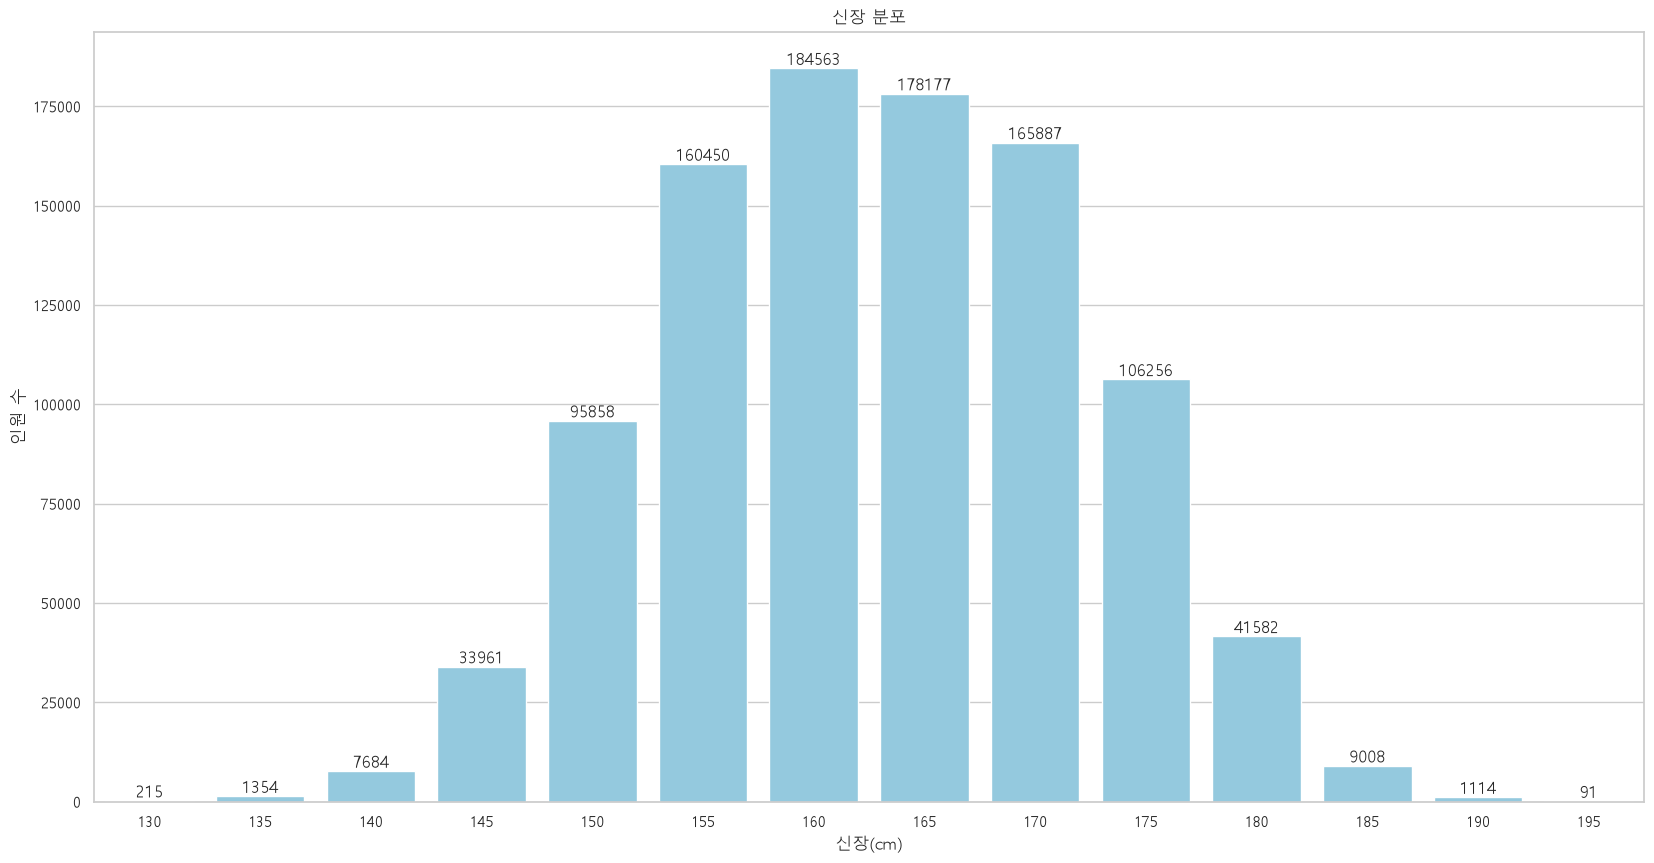

In [50]:
# 신장의 분포를 시각화해 살펴보세요
plt.figure(figsize = (20,10))
ax = sns.countplot(data = health_df, x = "신장", color = 'skyblue' )
plt.title("신장 분포")
plt.xlabel("신장(cm)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c,
                  fmt='{:.0f}',
                  label_type='edge');
plt.show()

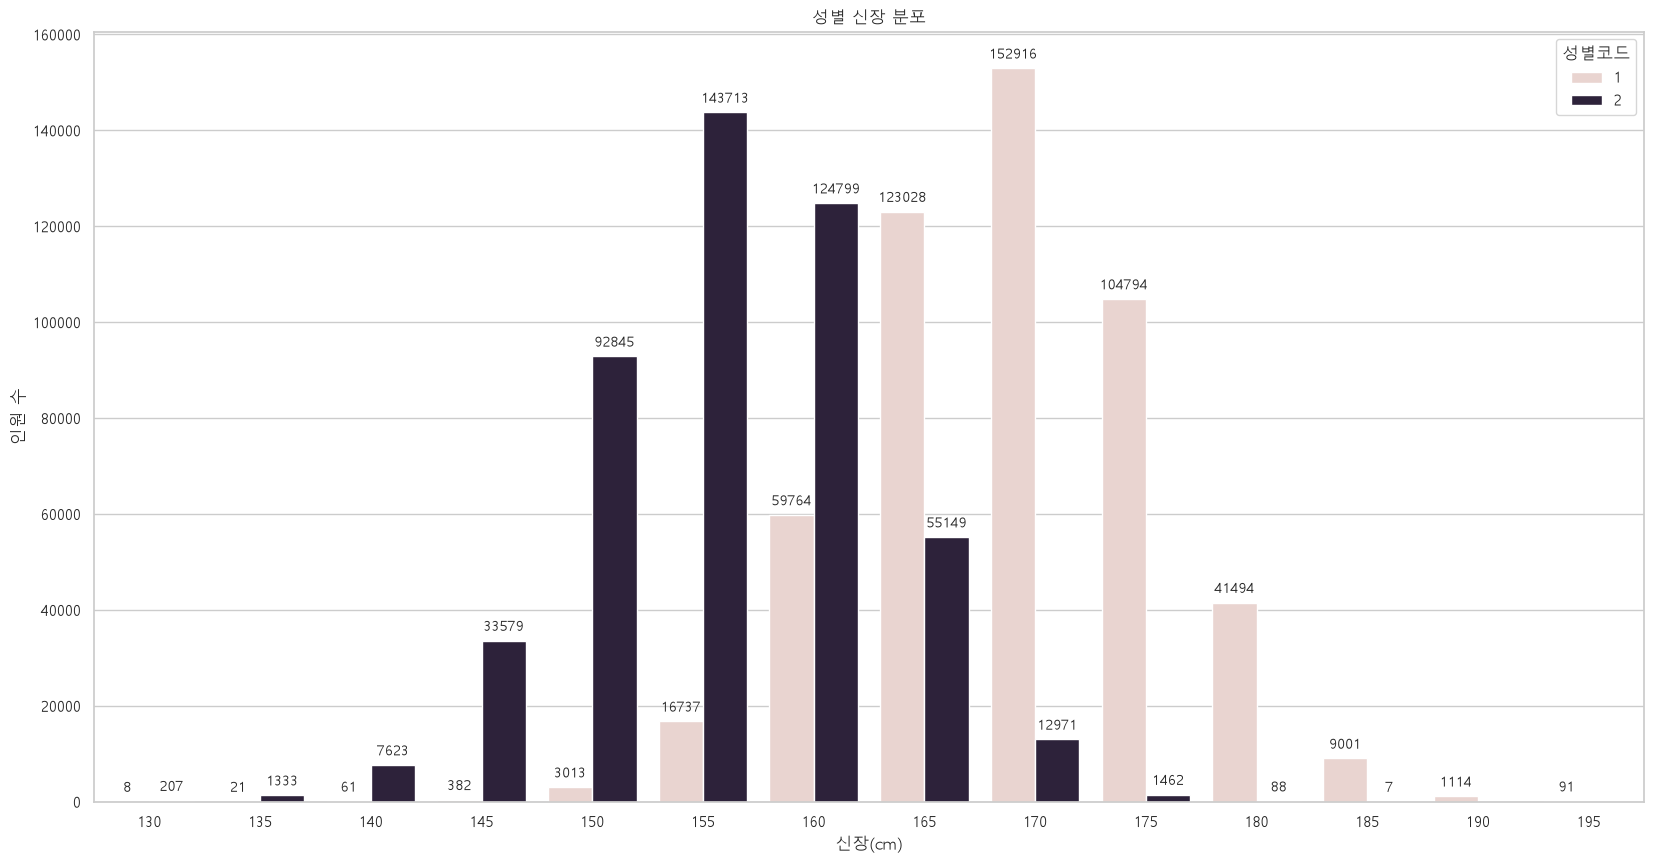

In [62]:
# 신장의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize = (20,10))
ax = sns.countplot(data = health_df, x = "신장",
                 hue = '성별코드')
plt.title("성별 신장 분포")
plt.xlabel("신장(cm)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c, fmt = '{:.0f}', label_type= 'edge', fontsize = 10, padding = 5)
plt.show()

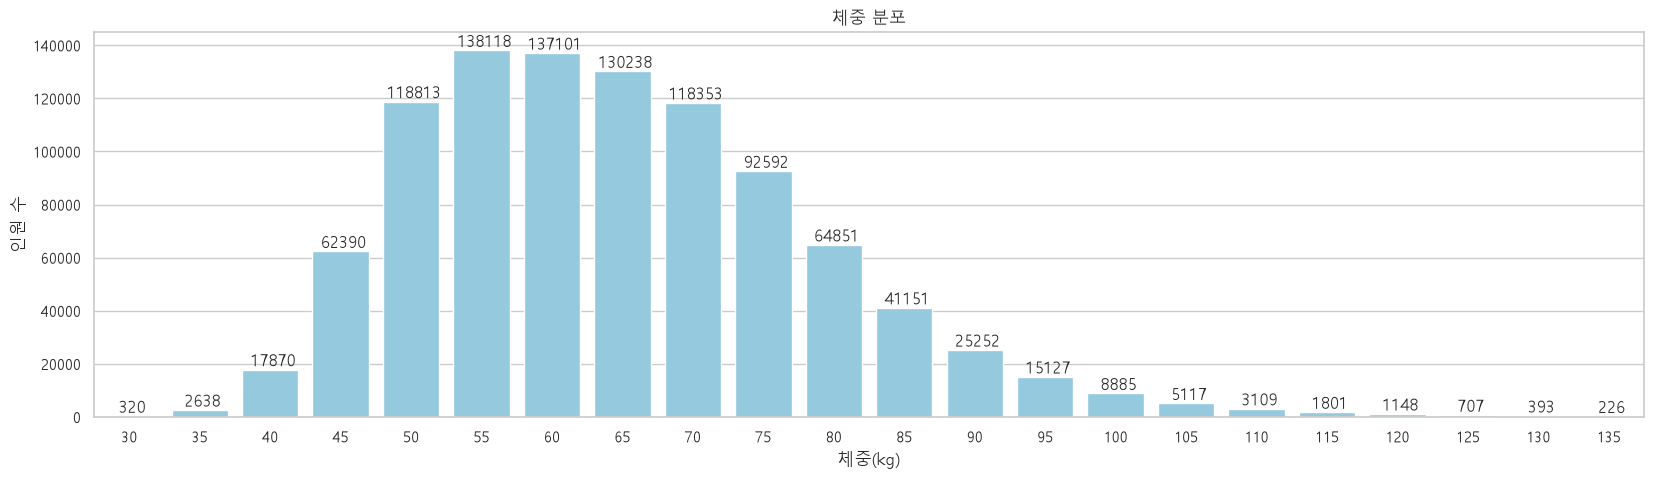

In [53]:
# 체중의 분포를 시각화해 살펴보세요
plt.figure(figsize = (20,5))
ax = sns.countplot(data = health_df, x = "체중", color = 'skyblue')
plt.title("체중 분포")
plt.xlabel("체중(kg)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge')
plt.show()

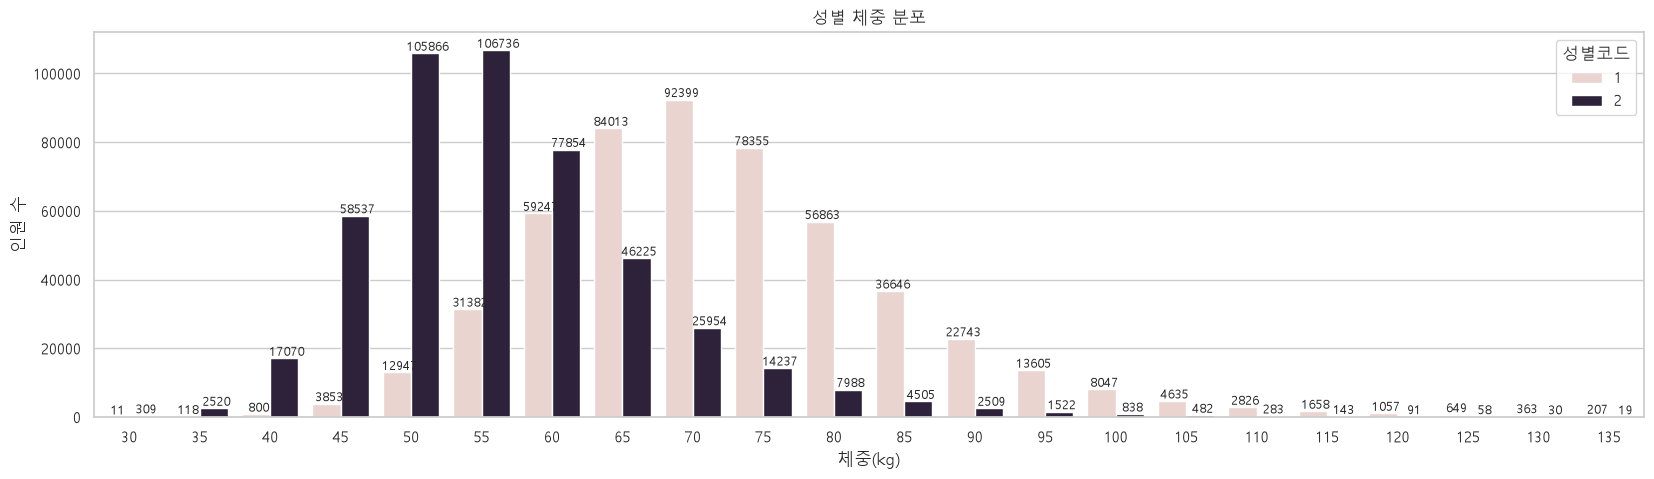

In [63]:
# 체중의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize = (20,5))
ax = sns.countplot(data = health_df, x = "체중", hue = "성별코드")
plt.title("성별 체중 분포")
plt.xlabel("체중(kg)")
plt.ylabel("인원 수")
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 9)
plt.show()

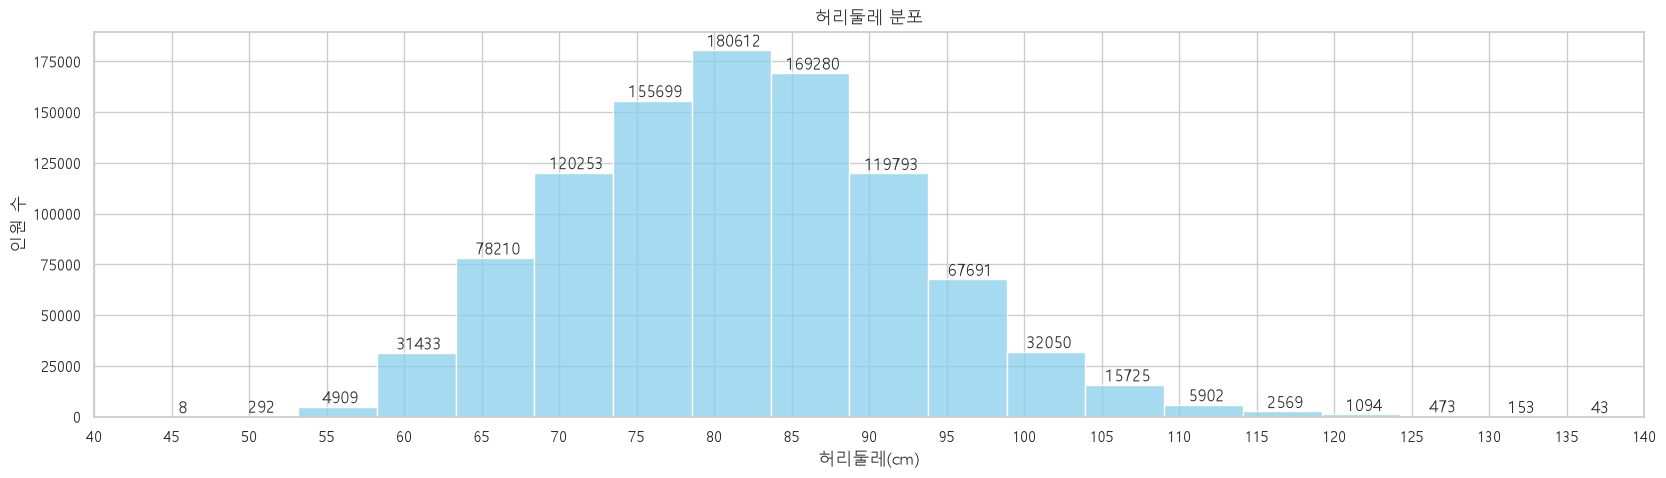

In [69]:
# 허리둘레의 분포를 시각화해 살펴보세요
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "허리둘레", color = 'skyblue', binwidth=5)
plt.title("허리둘레 분포")
plt.xlabel("허리둘레(cm)")
plt.ylabel("인원 수")
plt.xticks(np.arange(40,171,5))
plt.xlim(40, 140)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge')
plt.show()

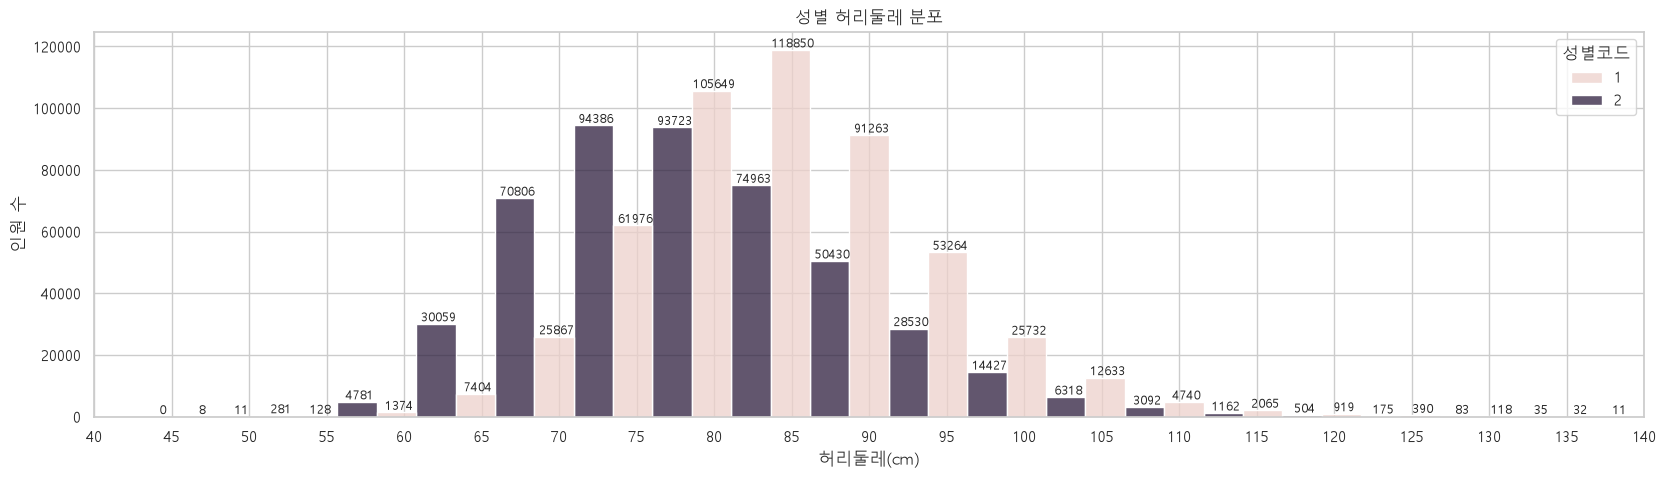

In [70]:
# 허리둘레의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "허리둘레", color = 'gray', binwidth=5, hue = "성별코드", multiple='dodge')
plt.title("성별 허리둘레 분포")
plt.xlabel("허리둘레(cm)")
plt.ylabel("인원 수")
plt.xticks(np.arange(40,171,5))
plt.xlim(40, 140)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 9)
plt.show()

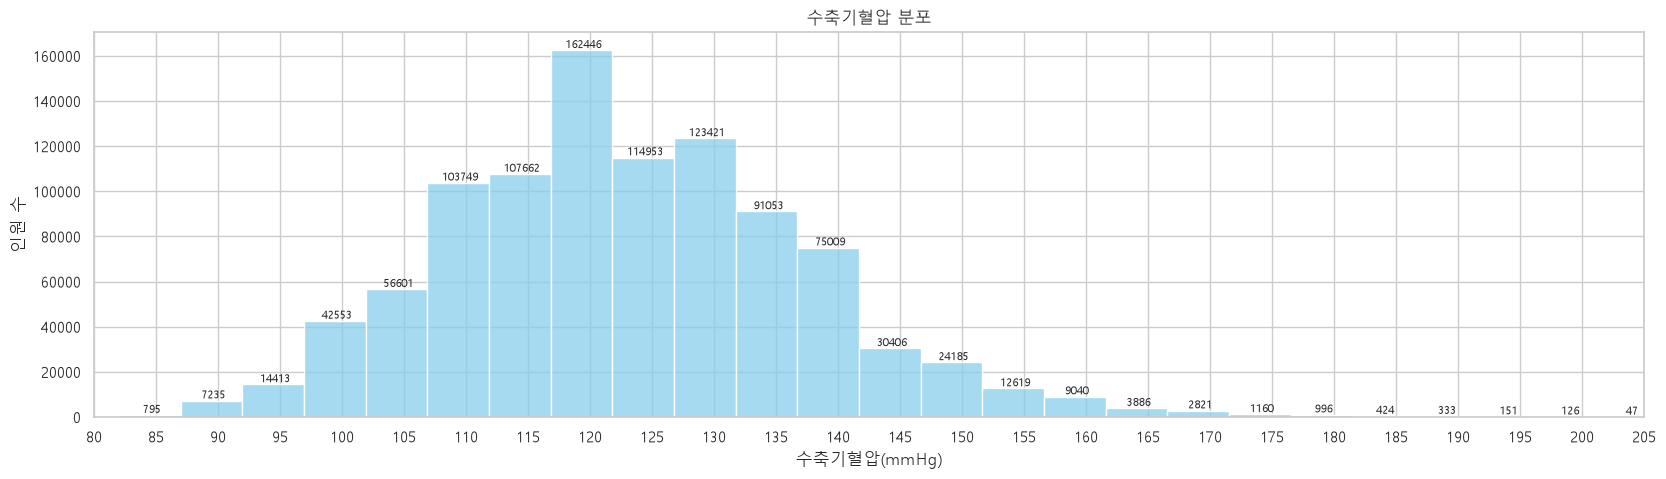

In [28]:
# 수축기혈압의 분포를 시각화해 살펴보세요
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "수축기혈압", color = 'skyblue', binwidth=5)
plt.title("수축기혈압 분포")
plt.xlabel("수축기혈압(mmHg)")
plt.ylabel("인원 수")
plt.xticks(np.arange(80,271,5))
plt.xlim(80, 205)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 8)
plt.show()

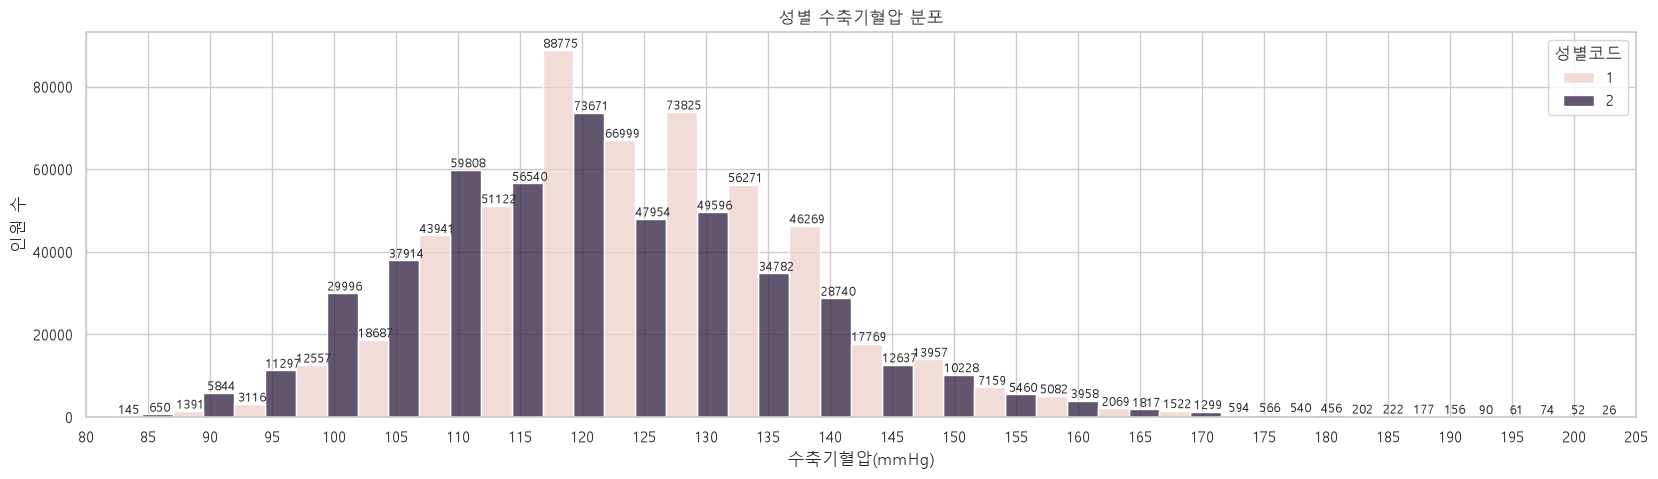

In [29]:
# 수축기혈압의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize = (20,5))
ax = sns.histplot(data = health_df, x = "수축기혈압", color = 'gray', binwidth=5, hue = "성별코드", multiple='dodge')
plt.title("성별 수축기혈압 분포")
plt.xlabel("수축기혈압(mmHg)")
plt.ylabel("인원 수")
plt.xticks(np.arange(80,271,5))
plt.xlim(80, 205)
for c in ax.containers:
    ax.bar_label(c, fmt = '{: .0f}', label_type='edge', fontsize = 9)
plt.show()

### 10\. 주요 수치형 변수 간 관계 분석
주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압) 간의 상관관계를 확인해 보세요.  
먼저 Pairplot으로 변수 간 관계를 시각화해 확인한 후, 변수 간 상관계수를 계산하고 히트맵으로 나타내보세요.

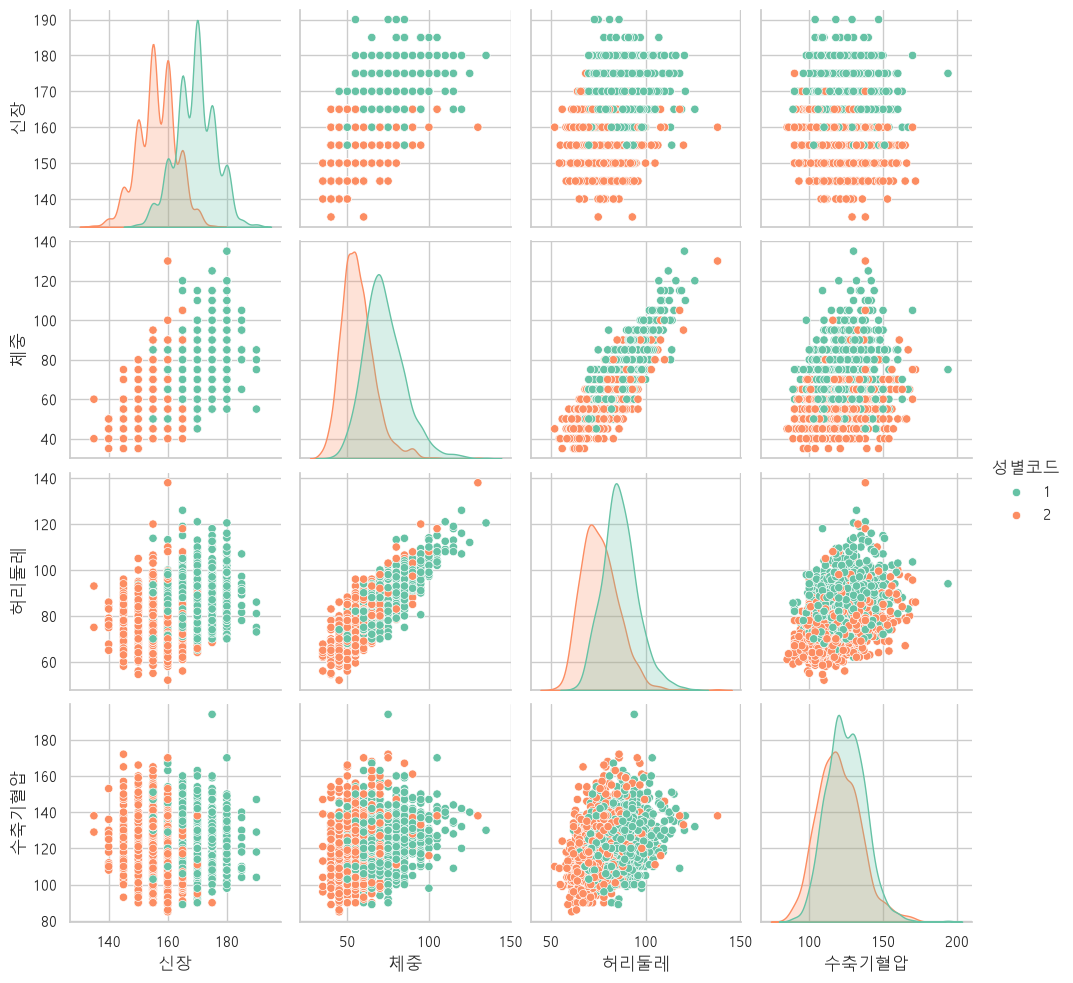

In [30]:
# Pairplot으로 변수 간 관계를 시각화하세요
cols = ['신장', '체중', '허리둘레', '수축기혈압']

sns.pairplot(data=health_df.sample(2000, random_state=42), vars=cols, hue="성별코드", palette="Set2")
plt.show()


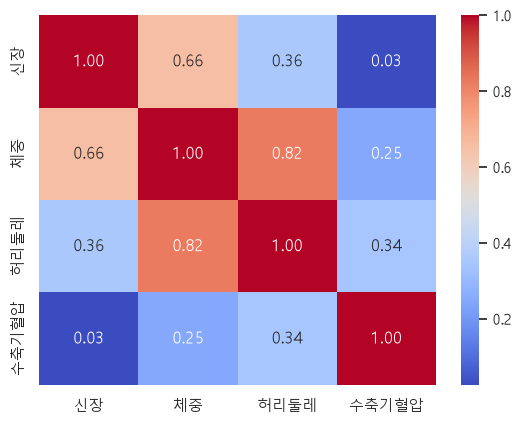

In [31]:
# 변수 간 상관계수를 계산하고 히트맵으로 나타내세요
corr = health_df[["신장", "체중", "허리둘레", "수축기혈압"]].corr()

sns.heatmap(corr, annot=True, cmap = 'coolwarm', fmt = ".2f")
plt.show()

### 11\. 연령대별 주요 건강 지표 분석
연령대별로 주요 건강 지표(신장, 체중, 허리둘레, 수축기혈압)이 어떻게 달라지는지 확인해 보세요.  
연령대별 평균값을 집계한 후, 연령 증가에 따라 각 지표가 어떻게 변하는지 시각화해 살펴보면 됩니다.

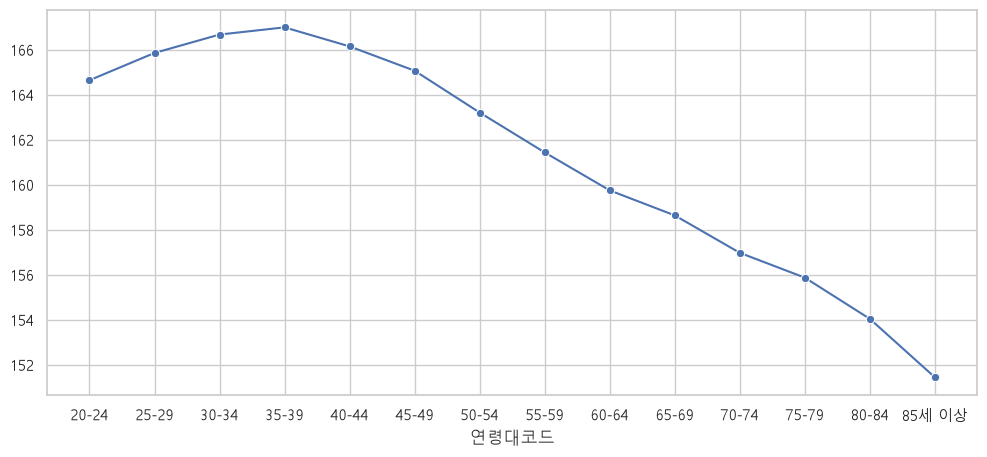

In [32]:
# 연령대별 신장 평균값을 비교해 보세요
age_height_mean = health_df.groupby("연령대코드")['신장'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x=age_height_mean.index, y=age_height_mean.values, marker='o')
plt.show()

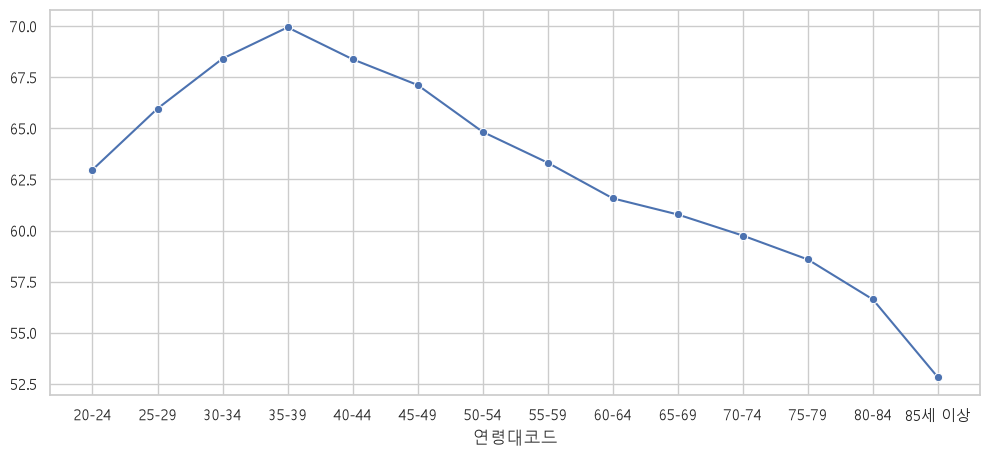

In [33]:
# 연령대별 체중 평균값을 비교해 보세요
age_weight_mean =health_df.groupby("연령대코드")['체중'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_weight_mean.index, y = age_weight_mean.values, marker= 'o')
plt.show()

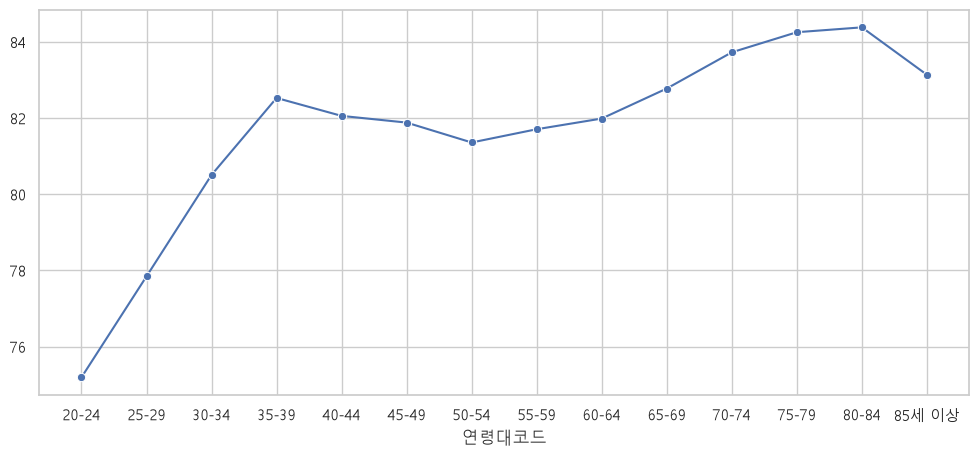

In [34]:
# 연령대별 허리둘레 평균값을 비교해 보세요
age_waist_mean = health_df.groupby("연령대코드")['허리둘레'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_waist_mean.index, y = age_waist_mean.values, marker= 'o')
plt.show()

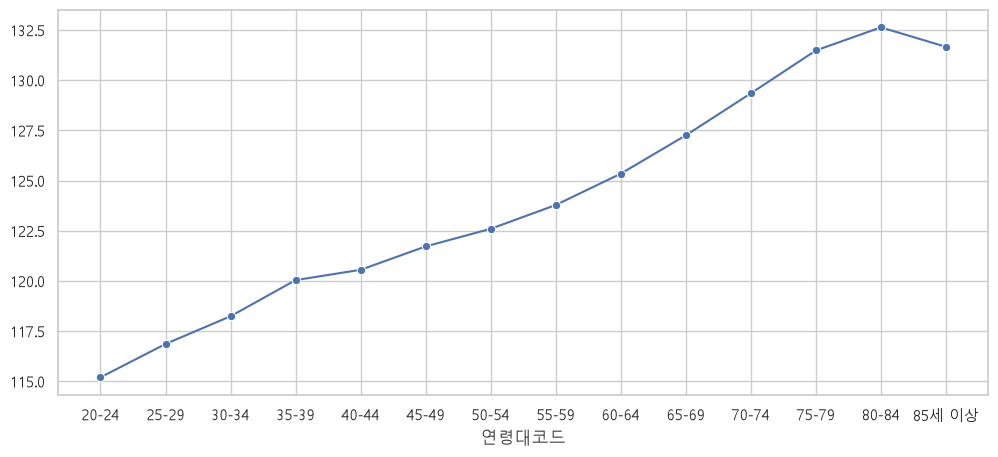

In [35]:
# 연령대별 수축기혈압 평균값을 비교해 보세요
age_blood_mean = health_df.groupby("연령대코드")['수축기혈압'].mean()

plt.figure(figsize = (12,5))
sns.lineplot(x= age_blood_mean.index, y = age_blood_mean.values, marker= 'o')
plt.show()

### 12\. 성별에 따른 흡연 및 음주 상태 비교

성별에 따라 흡연 및 음주 상태에 차이가 있는지 비교해 보세요. 수치로만 비교하는 걸 넘어 시각화까지 해서 살펴보면 더 좋습니다.

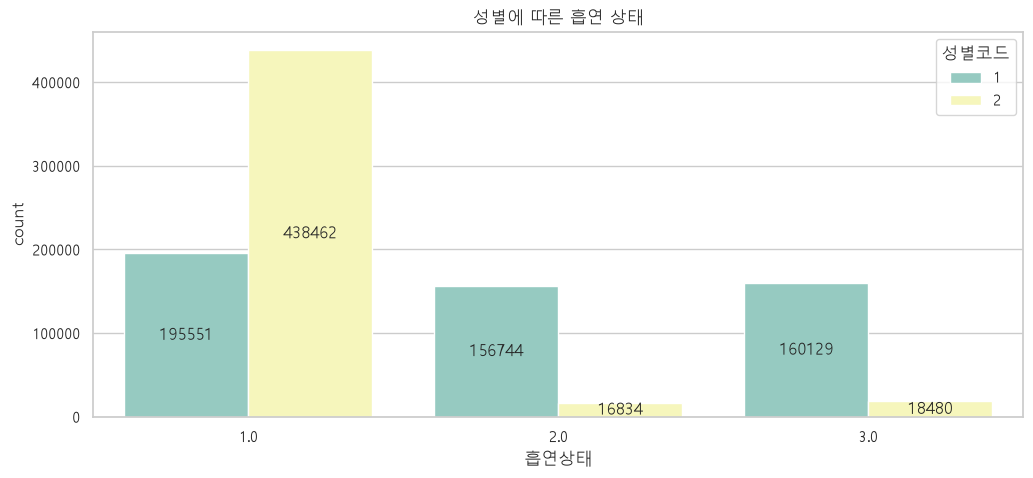

In [36]:
# 성별에 따른 흡연 상태를 비교해 보세요
plt.figure(figsize = (12,5))

ax = sns.countplot(data = health_df, x = "흡연상태", hue = '성별코드', palette = "Set3")
plt.title("성별에 따른 흡연 상태")
for c in ax.containers:
    ax.bar_label(c, fmt= '{:.0f}', label_type='center')

plt.show()

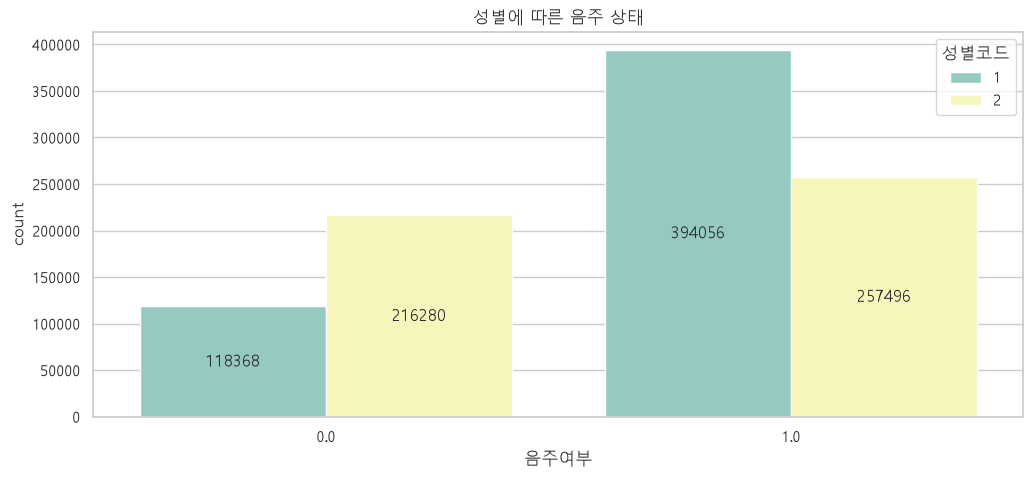

In [37]:
# 성별에 따른 음주 상태를 비교해 보세요
plt.figure(figsize = (12,5))

ax = sns.countplot(data = health_df, x = "음주여부", hue = '성별코드', palette = "Set3")
plt.title("성별에 따른 음주 상태")
for c in ax.containers:
    ax.bar_label(c, fmt= '{:.0f}', label_type='center')

plt.show()

### 13\. BMI 계산

BMI(체질량 지수)는 개인의 체중(kg)을 신장(m)의 제곱으로 나눈 값으로 계산하며, 비만도를 판단하는 데 널리 사용됩니다. BMI를 계산한 후 아래 기준에 따라 비만도를 판단해 보세요.  
BMI와 비만도 정보는 각각 새로운 컬럼을 생성해 저장합니다.

$$BMI= \frac{체중(kg)}{신장(m)^2}$$

BMI에 따른 비만도 판단 기준:

- 저체중: BMI < 18.5
- 정상 체중: 18.5 ≤ BMI < 25
- 과체중: 25 ≤ BMI < 30
- 비만: BMI ≥ 30

In [76]:
# 'BMI' 컬럼을 새로 생성하세요
health_df["BMI"] = round(health_df['체중'] / (health_df['신장']/100)**2,2)

In [82]:
# '비만도' 컬럼을 새로 생성하세요 (값: 저체중 / 정상 체중 / 과체중 / 비만)
health_df['비만도'] = health_df['BMI'].apply(lambda x:
                                          "저체중" if x < 18.5 else 
                                          "정상 체중" if 18.5 <= x < 25 else 
                                          "과체중" if 25 <= x < 30 else 
                                          "비만")
health_df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도
0,2024,4831755,경기도,2,60-64,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,1.0,1.0,19.53,정상 체중
1,2024,1154608,경기도,2,50-54,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,1.0,1.0,24.97,정상 체중
2,2024,3318236,경기도,2,60-64,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,1.0,1.0,24.44,정상 체중
3,2024,3770599,경기도,1,75-79,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,1.0,1.0,27.34,과체중
4,2024,2634185,경기도,1,50-54,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,1.0,1.0,21.22,정상 체중


### 14\. BMI 분포 시각화
전체적인 BMI 분포를 확인한 후, 성별에 따라 구분해서도 살펴보세요.

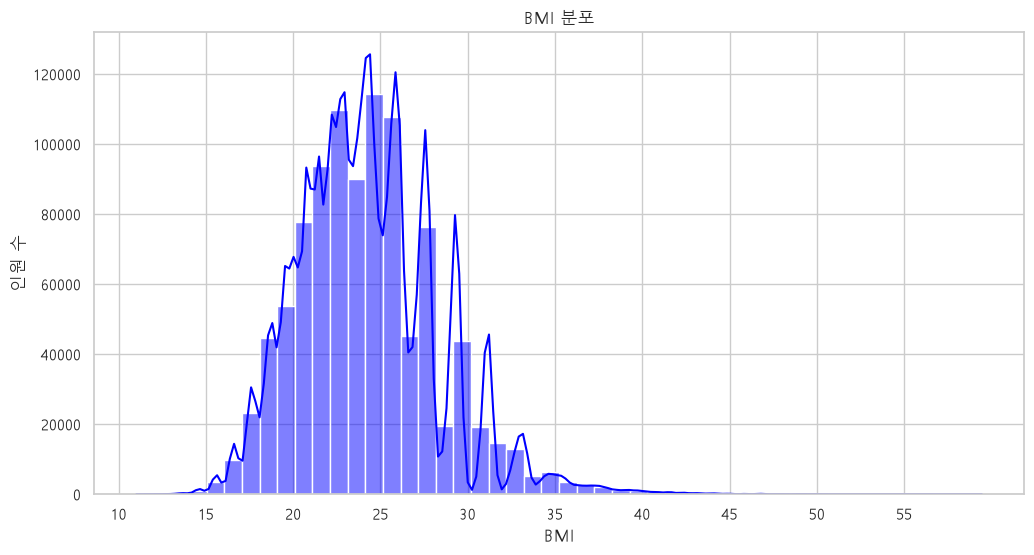

In [99]:
# 전체적인 BMI 분포를 시각화해 확인해 보세요
plt.figure(figsize = (12,6))
sns.histplot(data = health_df, x = "BMI", color = 'blue', kde = True, binwidth = 1)
plt.title("BMI 분포")
plt.xlabel("BMI")
plt.ylabel("인원 수")
plt.xticks(np.arange(10,60,5))
plt.show()

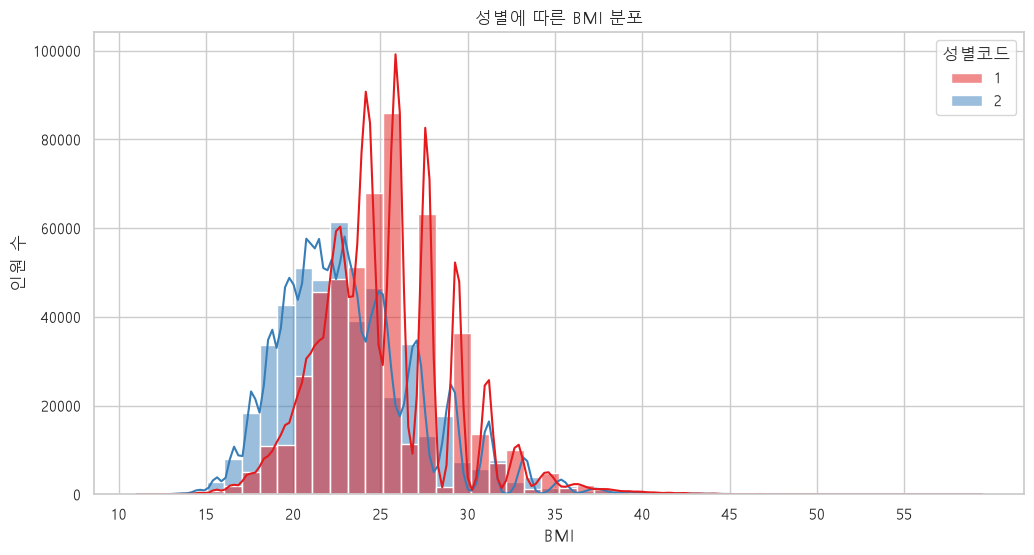

In [111]:
# BMI 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize = (12,6))
sns.histplot(data=health_df, x="BMI", hue="성별코드", palette="Set1", 
            binwidth=1, kde=True)
plt.title("성별에 따른 BMI 분포")
plt.xlabel("BMI")
plt.ylabel("인원 수")
plt.xticks(np.arange(10,60,5))
plt.show()

### 15\. 연령대별 BMI 및 비만도 비교
연령대별로 평균 BMI이 어떻게 달라지는지 시각화해서 비교해 보세요.  
그리고 연령대별로 비만도 그룹별로 인원 비중이 어떻게 다른지도 시각화해서 확인해 보세요. (예: "20~24세" 그룹은 저체중이 20%, 정상 체중이 50%, 과체중이 20%, 비만이 10%)

<Axes: xlabel='연령대코드'>

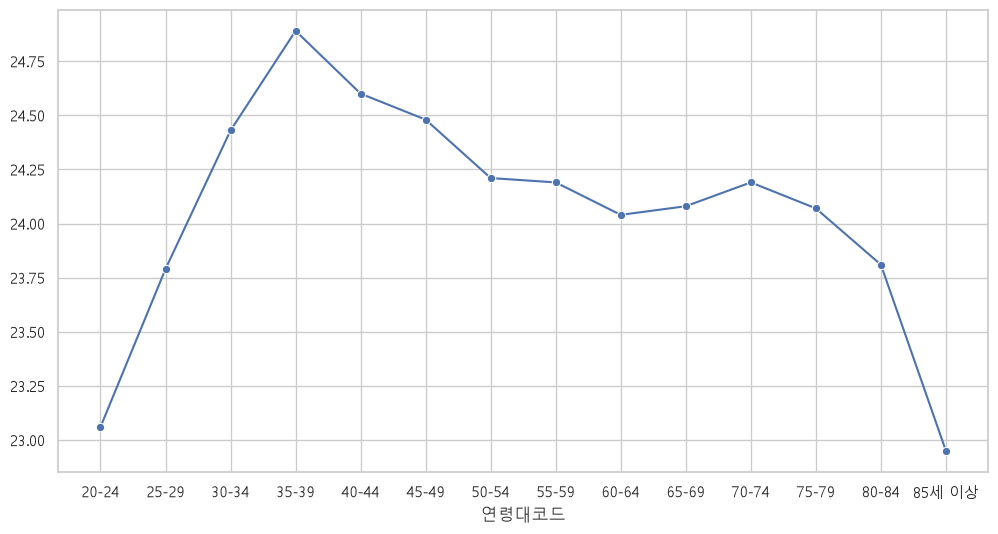

In [117]:
# 연령대별로 BMI 평균값을 비교해 보세요
age_BMI = round(health_df.groupby("연령대코드")["BMI"].mean(),2)

plt.figure(figsize = (12,6))
sns.lineplot(x = age_BMI.index, y = age_BMI.values, marker = 'o')

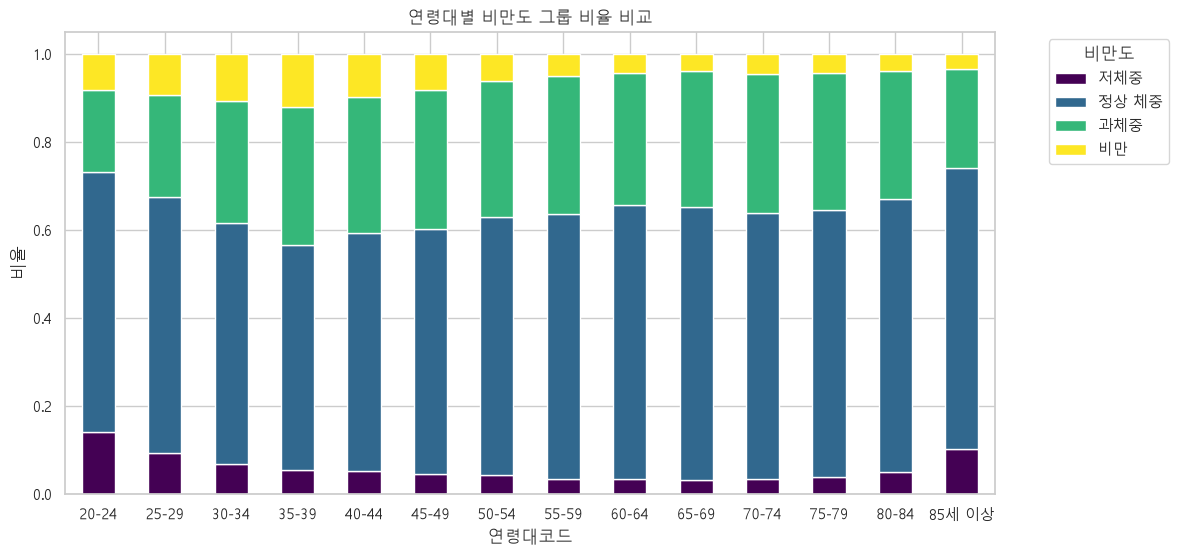

In [127]:
# 연령대별로 비만도 그룹별 인원 비중을 비교해 보세요
age_fat_ratio = pd.crosstab(health_df['연령대코드'], health_df['비만도'], normalize='index')

order = ['저체중', '정상 체중', '과체중', '비만']
age_fat_ratio = age_fat_ratio[order]

age_fat_ratio.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

plt.title("연령대별 비만도 그룹 비율 비교")
plt.xlabel("연령대코드")
plt.ylabel("비율")
plt.legend(title="비만도", bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 옆으로 배치
plt.xticks(rotation=0)
plt.show()


### 16\. BMI와 다른 건강 지표 간의 관계 분석

BMI와 다른 건강 지표(수축기혈압, 이완기혈압, 식전혈당) 간의 관계를 살펴보세요.  
먼저 산점도로 BMI와 다른 변수 간의 관계를 시각화해 확인한 후, 변수 간 상관계수를 계산하고 히트맵으로 나타내보세요.

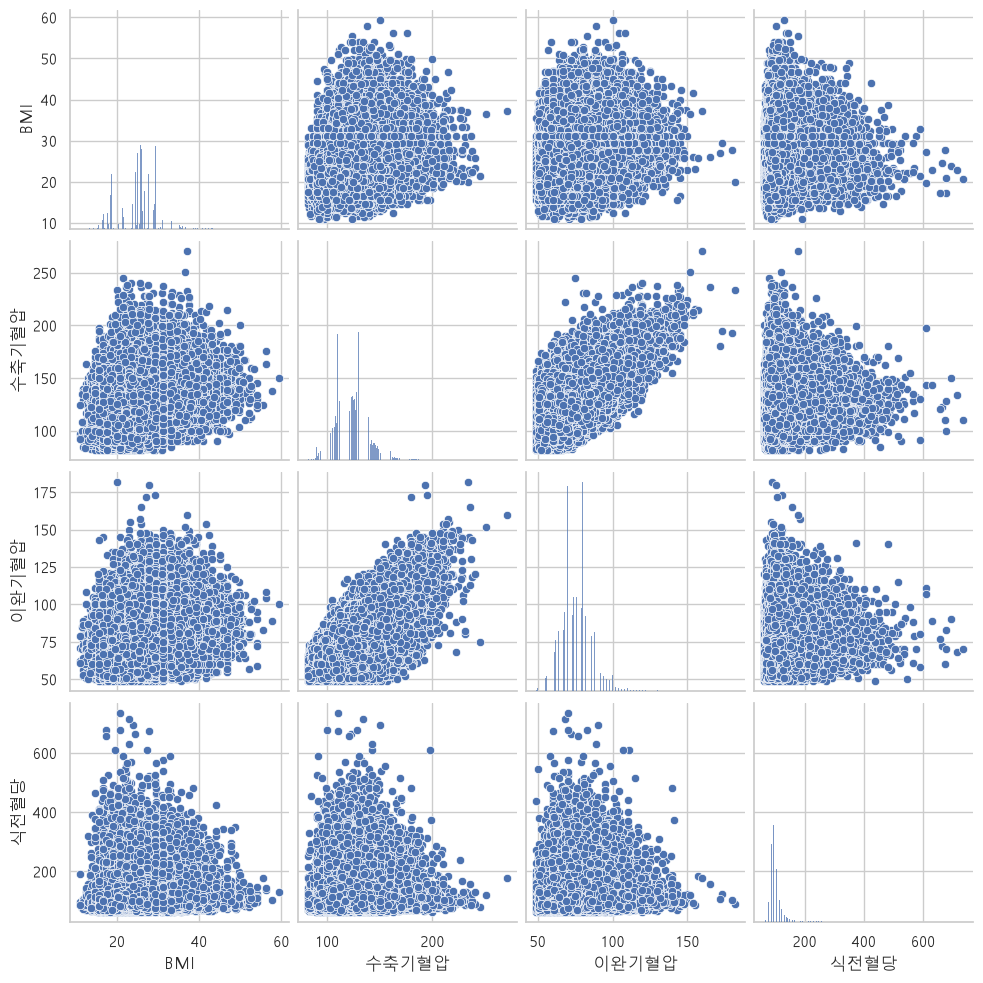

In [130]:
# 산점도로 BMI와 다른 변수 간 관계를 시각화하세요
cols = ['BMI', '수축기혈압', '이완기혈압', '식전혈당']

sns.pairplot(health_df[cols])
plt.show()

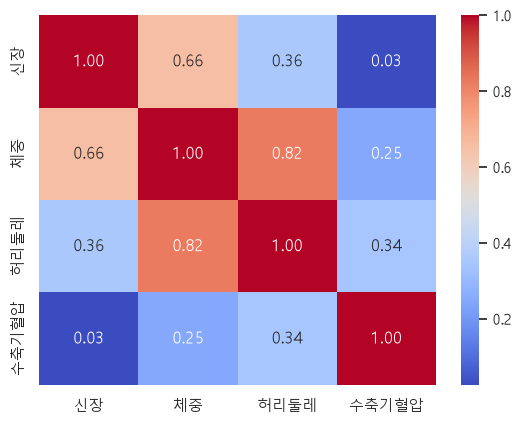

In [131]:
# 변수 간 상관계수를 계산하고 히트맵으로 나타내세요
corr = health_df[["신장", "체중", "허리둘레", "수축기혈압"]].corr()

sns.heatmap(corr, annot=True, cmap = 'coolwarm', fmt = ".2f")
plt.show()

### 17\. 비만도 그룹별 흡연 및 음주 상태 비교
비만도 그룹별로 흡연 및 음주 상태에 차이가 있는지 비교해 보세요. 수치로만 비교하는 걸 넘어 시각화까지 해서 살펴보면 더 좋습니다.

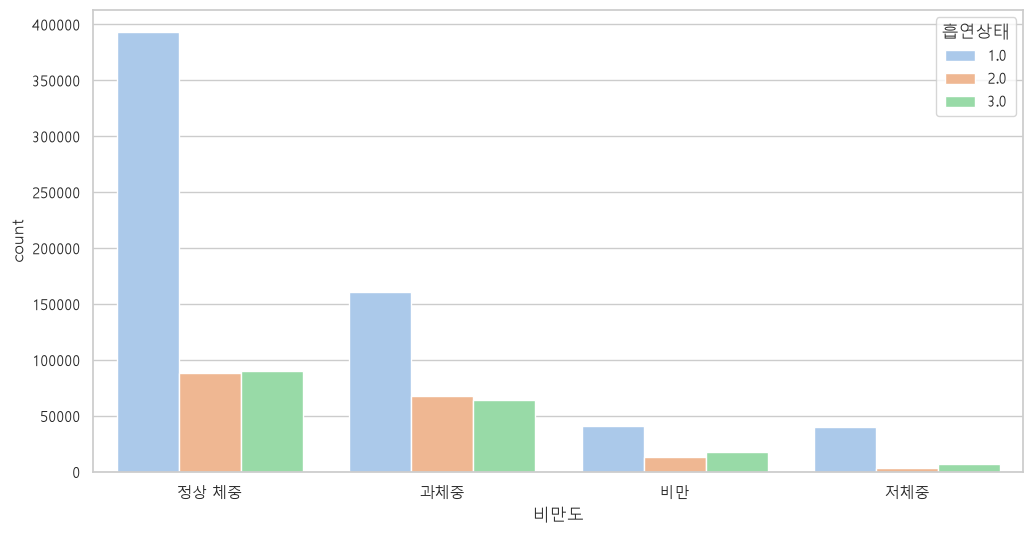

In [147]:
# 비만도 그룹별 흡연 상태를 비교해 보세요

plt.figure(figsize = (12,6))
sns.countplot(data = health_df, x = "비만도", hue = '흡연상태', palette= 'pastel')
plt.show()

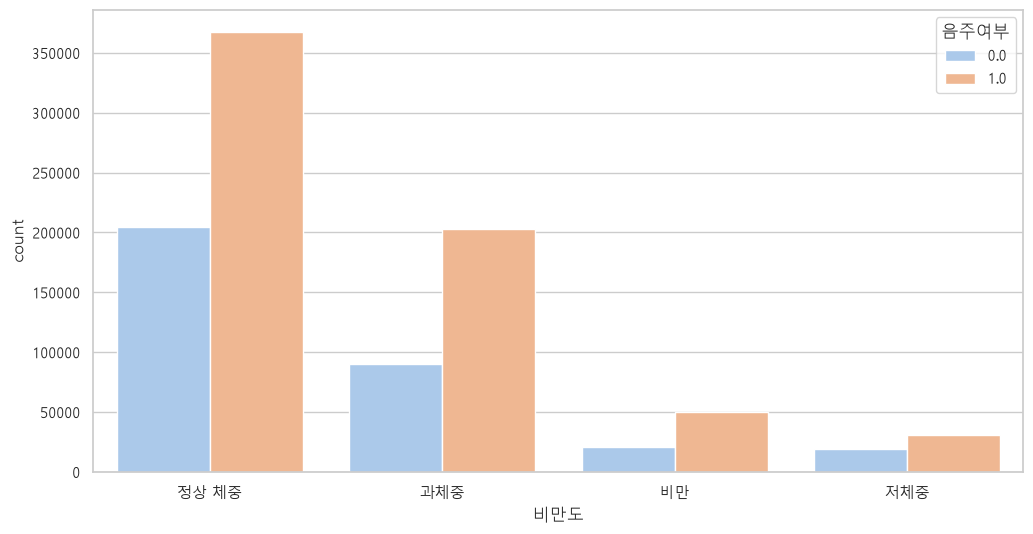

In [148]:
# 비만도 그룹별 음주 상태를 비교해 보세요
plt.figure(figsize = (12,6))
sns.countplot(data = health_df, x = "비만도", hue = '음주여부', palette= 'pastel')
plt.show()

---
## 심화 요구사항: 자유 EDA
주어진 데이터셋을 활용해 자유롭게 EDA(탐색적 데이터 분석)를 진행하세요.   
다양한 각도로 데이터를 관찰하다보면 데이터에 대한 이해를 높이고 생각하지 못했던 새로운 패턴을 찾아낼 수 있습니다.   
더 나아가, 발견한 내용을 알아보기 쉽게 정리하고 수치를 깔끔한 형태로 시각화하는 부분까지 신경쓰면 더욱 좋습니다.

In [48]:
# 자유롭게 코드를 입력하세요
